In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

In [5]:
file_path = r"C:\Users\phunk\OneDrive\Desktop\MyProject\Elder BKK\data\Raw Data.xlsx"
df = pd.read_excel(file_path)

In [6]:
df.head()

,REG,CWT,AREA,MEMBERS,SEX,AGE,AGE_GROUP,MARITAL,TOTAL_HR,APPROX,RE_ED
0,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,2,ชาย,53,45-59 ปี,โสด,48,15000,ปริญญาตรี
1,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,1,ชาย,31,30-44 ปี,โสด,48,15000,มัธยมศึกษาตอนต้น
2,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,4,ชาย,60,60 ปีขึ้นไป,ม่าย,48,10400,มัธยมศึกษาตอนต้น
3,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,1,หญิง,45,45-59 ปี,โสด,35,32000,ปริญญาโท
4,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,4,ชาย,37,30-44 ปี,โสด,48,45000,ปริญญาตรี


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3542 entries, 0 to 3541
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   REG        3542 non-null   str  
 1   CWT        3542 non-null   str  
 2   AREA       3542 non-null   str  
 3   MEMBERS    3542 non-null   int64
 4   SEX        3542 non-null   str  
 5   AGE        3542 non-null   int64
 6   AGE_GROUP  3542 non-null   str  
 7   MARITAL    3542 non-null   str  
 8   TOTAL_HR   3542 non-null   int64
 9   APPROX     3542 non-null   int64
 10  RE_ED      3542 non-null   str  
dtypes: int64(4), str(7)
memory usage: 304.5 KB


In [8]:
df.describe()

,MEMBERS,AGE,TOTAL_HR,APPROX
count,3542.000000,3542.000000,3542.000000,3542.000000
mean,2.473179,39.222473,44.665443,31686.312818
std,1.395008,11.685499,9.820337,109499.083468
min,1.000000,16.000000,0.000000,1500.000000
25%,1.000000,30.000000,40.000000,12000.000000
50%,2.000000,38.000000,48.000000,15000.000000
75%,3.000000,48.000000,48.000000,25000.000000
max,9.000000,81.000000,96.000000,999999.000000


In [9]:
for col in df.select_dtypes(include=["str"]).columns:
    print(f"{col}: {df[col].nunique()}")

REG: 1
CWT: 1
AREA: 1
SEX: 2
AGE_GROUP: 5
MARITAL: 6
RE_ED: 10


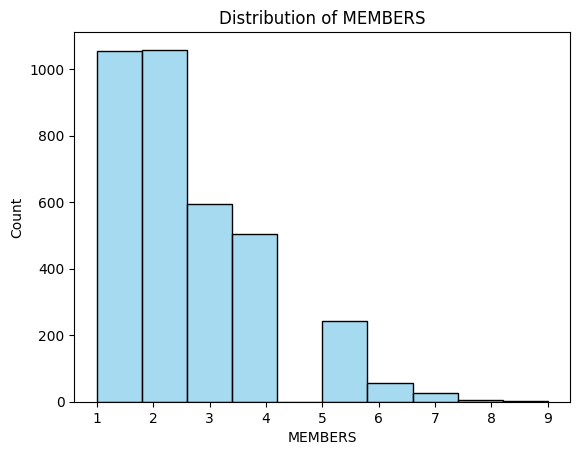

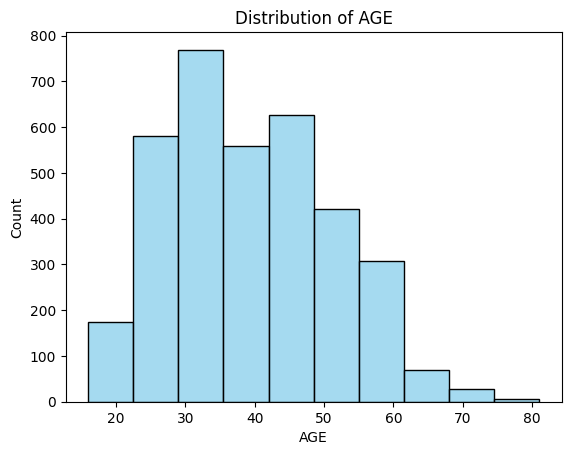

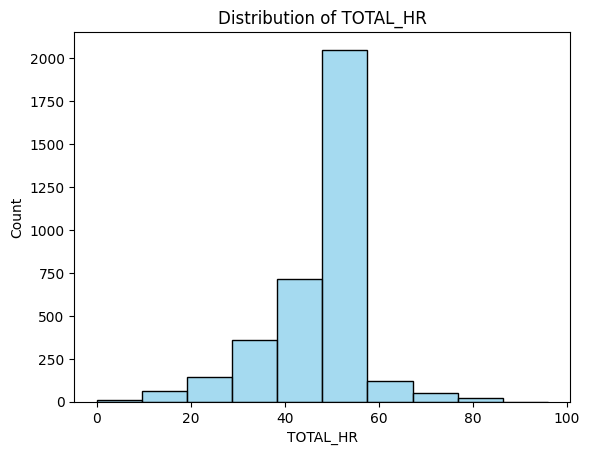

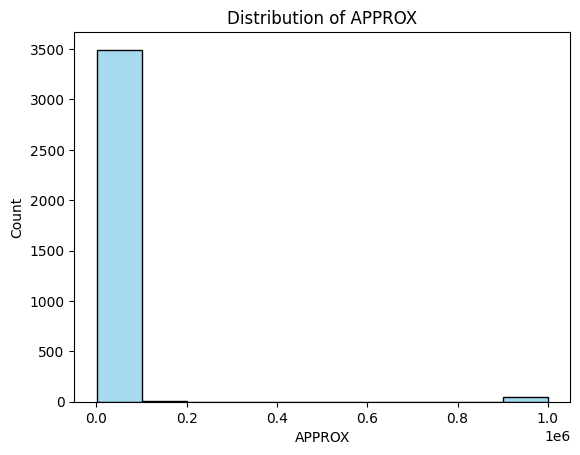

In [10]:
for col in df.select_dtypes(include="number").columns:
    plt.Figure(figsize=(10, 4))
    sns.histplot(df[col], bins=10, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.show()

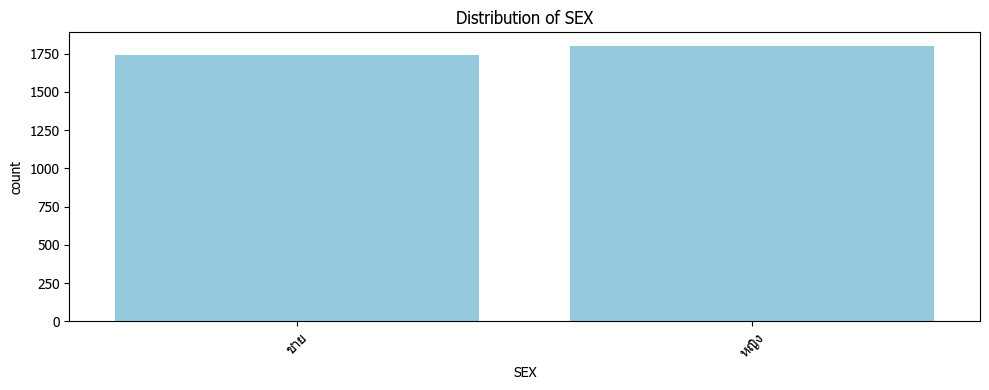

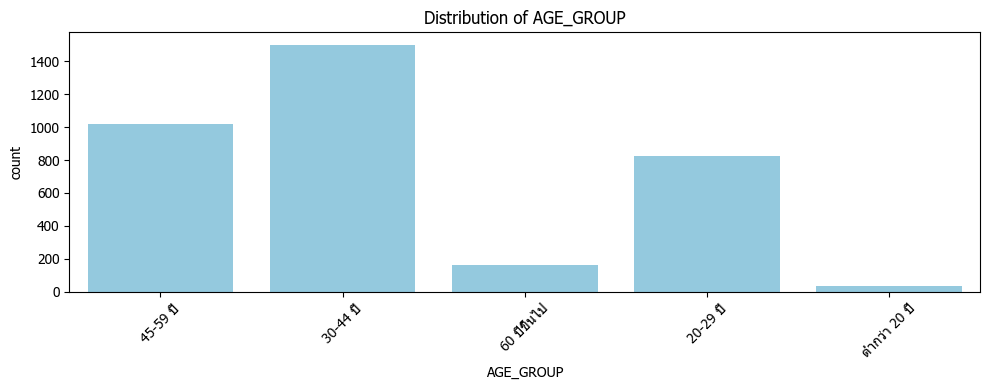

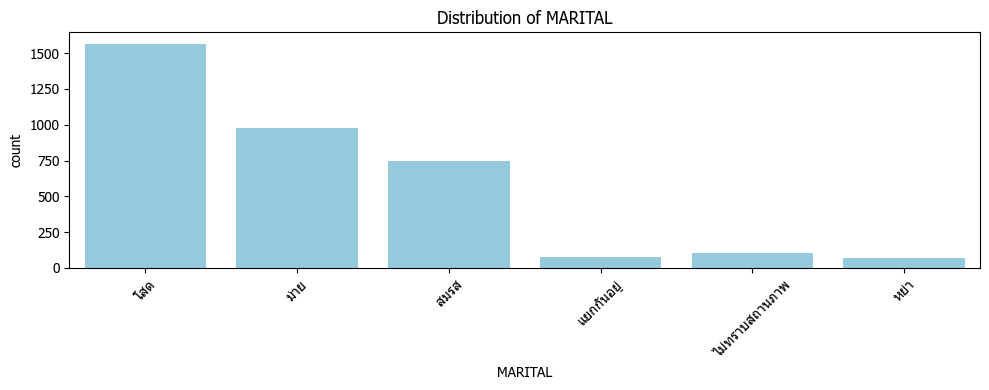

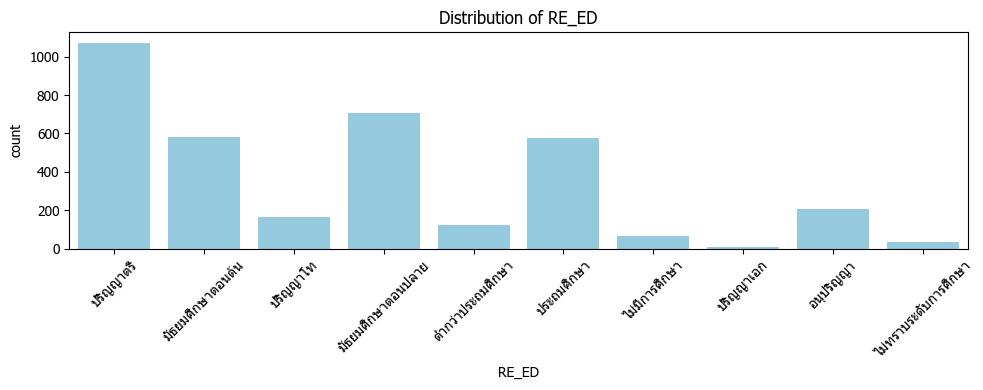

In [12]:
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

for col in df.select_dtypes(include=["object", "category", "string"]).columns.drop(["REG","CWT", "AREA"]):
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [13]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ AGE แบ่งตาม MARITAL")
print("=========================================================")
desc_stats = df.groupby('MARITAL')['AGE'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('AGE ~ C(MARITAL)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(MARITAL)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['AGE'], df['MARITAL'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('MARITAL')['AGE'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('MARITAL')['AGE'].mean().reset_index()
    rank_summary['MARITAL_STR'] = rank_summary['MARITAL'].astype(str)
    rank_summary['Group Sign'] = rank_summary['MARITAL_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='AGE', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['MARITAL', 'AGE', 'Group Sign']]
    rank_summary.columns = ['Marital Status (MARITAL)', 'Mean AGE', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ AGE แบ่งตาม MARITAL
                count  mean   std  min  median  max
MARITAL                                            
หย่า               71 56.18  9.83   26    55.0   81
แยกกันอยู่         76 48.32  8.79   27    49.5   67
ไม่ทราบสถานภาพ    106 47.91  9.49   22    50.0   66
สมรส              744 46.43 10.09   18    47.0   77
ม่าย              978 38.91 10.54   17    38.0   76
โสด              1567 34.20 10.24   16    32.0   78


 2. ANOVA Table
                   sum_sq      df           F         PR(>F)
C(MARITAL)  112998.870045     5.0  215.672876  2.642951e-201
Residual    370527.821090  3536.0         NaN            NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
  group1       group2     meandiff p-adj   lower    upper   reject
------------------------------------------------------------------
      ม่าย           สมรส  

In [14]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ AGE แบ่งตาม SEX")
print("=========================================================")
desc_stats = df.groupby('SEX')['AGE'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean AGE': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean AGE': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม SEX มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ AGE แบ่งตาม SEX
      count  mean   std  min  median  max
SEX                                      
ชาย    1743 39.39 11.65   16    38.0   77
หญิง   1799 39.06 11.72   17    38.0   81


 2. Two-Sample Z-Test Table
 Comparison Z-statistic P-value
ชาย vs หญิง      0.8549  0.3926

p-value ของ Z-Test คือ: 0.3926

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Gender (SEX) Mean AGE Statistical Group
Rank (Mean มากสุด)                                        
1                           ชาย  39.3930                 a
2                          หญิง  39.0573                 a
---------------------------------------------------------


In [16]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม AGE_GROUP")
print("=========================================================")
desc_stats = df.groupby('AGE_GROUP')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('TOTAL_HR ~ C(AGE_GROUP)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(AGE_GROUP)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['TOTAL_HR'], df['AGE_GROUP'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('AGE_GROUP')['TOTAL_HR'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('AGE_GROUP')['TOTAL_HR'].mean().reset_index()
    rank_summary['AGE_GROUP_STR'] = rank_summary['AGE_GROUP'].astype(str)
    rank_summary['Group Sign'] = rank_summary['AGE_GROUP_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='TOTAL_HR', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['AGE_GROUP', 'TOTAL_HR', 'Group Sign']]
    rank_summary.columns = ['Age Group (AGE_GROUP)', 'Mean TOTAL_HR', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม AGE_GROUP
               count  mean   std  min  median  max
AGE_GROUP                                         
20-29 ปี         826 45.77  9.23    0    48.0   96
ต่ำกว่า 20 ปี     36 45.42  8.54   16    48.0   60
30-44 ปี        1500 44.66  9.77    0    48.0   84
60 ปีขึ้นไป      161 44.34 11.69    0    48.0   84
45-59 ปี        1019 43.80 10.00    0    48.0   84


 2. ANOVA Table
                     sum_sq      df         F    PR(>F)
C(AGE_GROUP)    1794.981553     4.0  4.672456  0.000922
Residual      339695.568701  3537.0       NaN       NaN

p-value ของ ANOVA คือ: 0.0009

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
   20-29 ปี      30-44 ปี   -1.105 0.0701 -2.2639  0.0538  False
   20-29 ปี      45-59 ปี  -1.9626 

In [17]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม RE_ED")
print("=========================================================")
desc_stats = df.groupby('RE_ED')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('TOTAL_HR ~ C(RE_ED)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(RE_ED)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['TOTAL_HR'], df['RE_ED'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('RE_ED')['TOTAL_HR'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('RE_ED')['TOTAL_HR'].mean().reset_index()
    rank_summary['RE_ED_STR'] = rank_summary['RE_ED'].astype(str)
    rank_summary['Group Sign'] = rank_summary['RE_ED_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='TOTAL_HR', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['RE_ED', 'TOTAL_HR', 'Group Sign']]
    rank_summary.columns = ['Education Level (RE_ED)', 'Mean TOTAL_HR', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม RE_ED
                      count  mean   std  min  median  max
RE_ED                                                    
ไม่มีการศึกษา            66 50.52  5.99   40    48.0   72
ไม่ทราบระดับการศึกษา     32 48.78  9.80   24    48.0   72
มัธยมศึกษาตอนต้น        584 48.01  9.77    0    48.0   84
ประถมศึกษา              576 47.84  8.99    0    48.0   84
มัธยมศึกษาตอนปลาย       705 46.05  8.98    0    48.0   96
ต่ำกว่าประถมศึกษา       122 45.44  9.85    0    48.0   75
อนุปริญญา               209 44.28  8.69   14    48.0   84
ปริญญาตรี              1073 40.88  9.44    0    40.0   72
ปริญญาโท                164 38.13  8.61   12    40.0   54
ปริญญาเอก                11 31.00 10.24   14    35.0   40


 2. ANOVA Table
                 sum_sq      df          F        PR(>F)
C(RE_ED)   41043.123043     9.0  53.610529  7.567911e-92
Residual  300447.427211  3532.0        NaN           NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters 

In [18]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม SEX")
print("=========================================================")
desc_stats = df.groupby('SEX')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean TOTAL_HR': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean TOTAL_HR': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม SEX มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม SEX
      count  mean  std  min  median  max
SEX                                     
ชาย    1743 45.10 9.93    0    48.0   84
หญิง   1799 44.24 9.70    0    48.0   96


 2. Two-Sample Z-Test Table
 Comparison Z-statistic P-value
ชาย vs หญิง      2.5924  0.0095

p-value ของ Z-Test คือ: 0.0095

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Gender (SEX) Mean TOTAL_HR Statistical Group
Rank (Mean มากสุด)                                             
1                           ชาย       45.0998                 a
2                          หญิง       44.2446                 b
---------------------------------------------------------


In [20]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม AGE_GROUP")
print("=========================================================")
desc_stats = df.groupby('AGE_GROUP')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราวเพื่อดูภาพรวม
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Kruskal-Wallis Test")
print("=========================================================")
# เตรียมข้อมูลแยกกลุ่มตาม AGE_GROUP
groups_data = [group['APPROX'].values for name, group in df.groupby('AGE_GROUP')]

kw_stat, p_value = stats.kruskal(*groups_data)

kw_table = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'H-statistic': [kw_stat],
    'P-value': [p_value]
})
print(kw_table.to_string(index=False, formatters={'H-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
print(f"\np-value ของ Kruskal-Wallis คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis (Dunn's test) & Group Letters")
    print("=========================================================")
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณอันดับ (Ranks) ของข้อมูลทั้งหมด
    df['APPROX_RANK'] = df['APPROX'].rank()
    
    # คำนวณ Mean Rank ของแต่ละกลุ่มเพื่อใช้เรียงลำดับในรายงาน
    mean_ranks = df.groupby('AGE_GROUP')['APPROX_RANK'].mean()
    sorted_groups = mean_ranks.sort_values(ascending=False).index.tolist()
    
    # ทำ Post-hoc Dunn's test โดยใช้ MultiComparison บน Ranks
    mc = MultiComparison(df['APPROX_RANK'], df['AGE_GROUP'])
    tukey_result = mc.tukeyhsd()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    # สร้าง Adjacency Matrix เพื่อตรวจสอบคู่ที่แตกต่างกันทางสถิติ
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    # ค้นหากลุ่มที่เป็นก้อนเดียวกันทางสถิติ (Cliques)
    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    # แจกจ่ายกลุ่มอักษรทางสถิติ (Compact Letter Display)
    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    # แสดงตารางสรุปผลลัพธ์ที่รวมเอาคุณสมบัติสำหรับเขียนเล่มรายงาน
    rank_summary = df.groupby('AGE_GROUP').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['AGE_GROUP_STR'] = rank_summary['AGE_GROUP'].astype(str)
    rank_summary['Group Sign'] = rank_summary['AGE_GROUP_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['AGE_GROUP', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Age Group (AGE_GROUP)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ขยะที่สร้างชั่วคราวทิ้ง
    df.drop(columns=['APPROX_RANK'], inplace=True)

else:
    print("ผลการทดสอบ Kruskal-Wallis ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม AGE_GROUP
               count      mean        std   min    median     max
AGE_GROUP                                                        
30-44 ปี        1500 32,676.84 110,280.28  1500 17,000.00  999999
45-59 ปี        1019 35,063.91 111,238.13  2000 16,500.00  999999
20-29 ปี         826 27,056.91 107,979.41  2400 14,000.00  999999
60 ปีขึ้นไป      161 29,622.73 110,743.68  2000 12,000.00  999999
ต่ำกว่า 20 ปี     36 10,257.44   2,674.90  2648 10,000.00   15000


 2. Kruskal-Wallis Test
          Test H-statistic P-value
Kruskal-Wallis    189.7235  0.0000

p-value ของ Kruskal-Wallis คือ: 0.0000

 3. Post-hoc Analysis (Dunn's test) & Group Letters
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------------------------
                        Age Group (AGE_GROUP) Median APPROX Mean Rank Statistical Group
R

In [21]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม RE_ED")
print("=========================================================")
desc_stats = df.groupby('RE_ED')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median เพื่อดูแนวโน้มเบื้องต้น
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Kruskal-Wallis Test")
print("=========================================================")
# เตรียมข้อมูลแยกกลุ่มตาม RE_ED
groups_data = [group['APPROX'].values for name, group in df.groupby('RE_ED')]

kw_stat, p_value = stats.kruskal(*groups_data)

kw_table = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'H-statistic': [kw_stat],
    'P-value': [p_value]
})
print(kw_table.to_string(index=False, formatters={'H-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
print(f"\np-value ของ Kruskal-Wallis คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis (Dunn's test) & Group Letters")
    print("=========================================================")
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณอันดับ (Ranks) ของข้อมูลทั้งหมด
    df['APPROX_RANK'] = df['APPROX'].rank()
    
    # คำนวณ Mean Rank ของแต่ละกลุ่มเพื่อใช้เรียงลำดับความสำคัญในเล่มรายงาน
    mean_ranks = df.groupby('RE_ED')['APPROX_RANK'].mean()
    sorted_groups = mean_ranks.sort_values(ascending=False).index.tolist()
    
    # ทำ Post-hoc Dunn's test โดยใช้ MultiComparison บน Ranks
    mc = MultiComparison(df['APPROX_RANK'], df['RE_ED'])
    tukey_result = mc.tukeyhsd()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    # สร้าง Adjacency Matrix เพื่อเช็กคู่ที่มีนัยสำคัญทางสถิติ
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    # ค้นหากลุ่มที่เป็นเซตเดียวกันทางสถิติ (Cliques)
    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    # แจกจ่ายสัญลักษณ์กลุ่มตัวอักษร (Compact Letter Display)
    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    # แสดงตารางสรุปผลลัพธ์แบบเบ็ดเสร็จเพื่อนำไปกรอกลงเล่มรายงาน
    rank_summary = df.groupby('RE_ED').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['RE_ED_STR'] = rank_summary['RE_ED'].astype(str)
    rank_summary['Group Sign'] = rank_summary['RE_ED_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['RE_ED', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Education Level (RE_ED)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ที่สร้างขึ้นชั่วคราวออกจาก DataFrame
    df.drop(columns=['APPROX_RANK'], inplace=True)

else:
    print("ผลการทดสอบ Kruskal-Wallis ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม RE_ED
                      count      mean        std    min    median     max
RE_ED                                                                    
ปริญญาเอก                11 55,909.09  18,278.15  30000 50,000.00   80000
ปริญญาโท                164 67,121.01 150,727.79  15000 39,500.00  999999
ปริญญาตรี              1073 48,248.82 141,659.50   1500 25,000.00  999999
อนุปริญญา               209 32,804.28 117,272.13   8000 17,000.00  999999
มัธยมศึกษาตอนปลาย       705 22,297.53  82,947.73   2400 14,000.00  999999
มัธยมศึกษาตอนต้น        584 21,955.21  91,068.88   2648 12,500.00  999999
ประถมศึกษา              576 15,566.39  58,285.16   2500 12,000.00  999999
ต่ำกว่าประถมศึกษา       122 11,442.46   4,987.45   2000 10,200.00   37500
ไม่ทราบระดับการศึกษา     32 74,685.38 242,853.48   4000 10,000.00  999999
ไม่มีการศึกษา            66 10,443.06   3,482.26   3000  9,189.00   30000


 2. Kruskal-Wallis Test
          Test H-statistic P-value
Kruskal-

In [22]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม SEX")
print("=========================================================")
desc_stats = df.groupby('SEX')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราว
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Mann-Whitney U Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    # แยกข้อมูล 2 กลุ่มตามเพศ
    data1 = df[df['SEX'] == g1]['APPROX'].values
    data2 = df[df['SEX'] == g2]['APPROX'].values
    
    # คำนวณ Mann-Whitney U Test
    u_stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    
    u_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'U-statistic': [u_stat],
        'P-value': [p_value]
    })
    print(u_table.to_string(index=False, formatters={'U-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Mann-Whitney U Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    print("=========================================================")
    print(" 3. สรุปผลการจัดอันดับ (Rank) และกลุ่มตัวอักษร")
    print("=========================================================")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณ Mean Rank เพื่อใช้รายงานในตาราง
    df['APPROX_RANK'] = df['APPROX'].rank()
    mean_ranks = df.groupby('SEX')['APPROX_RANK'].mean()
    
    # กำหนดอักษรกลุ่มตามระดับนัยสำคัญทางสถิติ
    if p_value < 0.05:
        if mean_ranks[g1] > mean_ranks[g2]:
            letters = {g1: 'a', g2: 'b'}
        else:
            letters = {g1: 'b', g2: 'a'}
    else:
        letters = {g1: 'a', g2: 'a'}
        
    # สร้างตารางสรุป
    rank_summary = df.groupby('SEX').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['SEX_STR'] = rank_summary['SEX'].astype(str)
    rank_summary['Group Sign'] = rank_summary['SEX_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['SEX', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Gender (SEX)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ที่สร้างขึ้นชั่วคราว
    df.drop(columns=['APPROX_RANK'], inplace=True)
    
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม SEX มีจำนวน {len(groups)} กลุ่ม (Mann-Whitney U Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม SEX
      count      mean        std   min    median     max
SEX                                                     
ชาย    1743 30,767.67 102,623.41  2000 15,000.00  999999
หญิง   1799 32,576.36 115,793.63  1500 15,000.00  999999


 2. Mann-Whitney U Test Table
 Comparison    U-statistic P-value
ชาย vs หญิง 1,690,119.0000  0.0001

p-value ของ Mann-Whitney U Test คือ: 0.0001

 3. สรุปผลการจัดอันดับ (Rank) และกลุ่มตัวอักษร
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------------------------
                        Gender (SEX) Median APPROX Mean Rank Statistical Group
Rank (Mean Rank มากสุด)                                                       
1                                ชาย     15,000.00  1,841.66                 a
2                               หญิง     15,000.00  1,703.52                 b
---------------------------------------------------------


In [23]:
ed_ordinal_mapping = {
    'ไม่มีการศึกษา': 1,
    'ต่ำกว่าประถมศึกษา': 2,
    'ประถมศึกษา': 3,
    'มัธยมศึกษาตอนต้น': 4,
    'มัธยมศึกษาตอนปลาย': 5,
    'อนุปริญญา': 6,
    'ปริญญาตรี': 7,
    'ปริญญาโท': 8,
    'ปริญญาเอก': 9,
    'ไม่ทราบระดับการศึกษา': np.nan,  # แปลงเป็น NaN เพื่อไม่ให้กวนสถิติอันดับ
    'อื่นๆ': np.nan                  # แปลงเป็น NaN เพื่อไม่ให้กวนสถิติอันดับ
}

# แปลงข้อมูลในคอลัมน์ RE_ED เป็นตัวแปรอันดับ (Ordinal) ในคอลัมน์ใหม่
df['RE_ED_ORDINAL'] = df['RE_ED'].map(ed_ordinal_mapping)

# เช็กผลลัพธ์การแปลงเบื้องต้น
print("ตรวจสอบการแปลงข้อมูล:")
print(df[['RE_ED', 'RE_ED_ORDINAL']].drop_duplicates().sort_values(by='RE_ED_ORDINAL'))

ตรวจสอบการแปลงข้อมูล:
                    RE_ED  RE_ED_ORDINAL
26          ไม่มีการศึกษา            1.0
16      ต่ำกว่าประถมศึกษา            2.0
19             ประถมศึกษา            3.0
1        มัธยมศึกษาตอนต้น            4.0
6       มัธยมศึกษาตอนปลาย            5.0
61              อนุปริญญา            6.0
0               ปริญญาตรี            7.0
3                ปริญญาโท            8.0
53              ปริญญาเอก            9.0
331  ไม่ทราบระดับการศึกษา            NaN


In [24]:
# 1. ระบุลิสต์ตัวแปรที่ต้องการคำนวณ
num_vars = ['AGE', 'TOTAL_HR', 'APPROX', 'RE_ED_ORDINAL']

# ลบแถวที่มีค่าว่าง (NaN) เฉพาะในกลุ่มตัวแปรเหล่านี้ เพื่อให้ Matrix สมบูรณ์
df_clean = df[num_vars].dropna()


# --- ส่วนที่ 1: คำนวณตารางค่า r มาตรฐาน ---
spearman_matrix = pd.DataFrame(index=num_vars, columns=num_vars)
# --- ส่วนที่ 2: คำนวณตารางค่า R-Squared (%) ---
r2_percentage_matrix = pd.DataFrame(index=num_vars, columns=num_vars)

# ลูปจับคู่ตัวแปรวิ่งชนกันทุกคู่เพื่อคำนวณค่าทางสถิติ
for col1 in num_vars:
    for col2 in num_vars:
        if col1 == col2:
            spearman_matrix.loc[col1, col2] = "1.00"
            r2_percentage_matrix.loc[col1, col2] = "100.0%"
        else:
            # คำนวณค่า r และ p-value ด้วย Spearman's Rho
            r, p = stats.spearmanr(df_clean[col1], df_clean[col2])
            
            # คำนวณค่า R-Squared เป็นเปอร์เซ็นต์ (r^2 * 100)
            r2_pct = (r ** 2) * 100
            
            # หาดอกจันตามระดับ p-value
            stars = ""
            if p < 0.001:
                stars = "***"
            elif p < 0.01:
                stars = "**"
            elif p < 0.05:
                stars = "*"
            
            # บันทึกค่าลงในตาราง r ปกติ
            spearman_matrix.loc[col1, col2] = f"{r:.2f}{stars}"
            
            # บันทึกค่าลงในตาราง เปอร์เซ็นต์อธิบายความผันแปร (R-squared %)
            r2_percentage_matrix.loc[col1, col2] = f"{r2_pct:.2f}%{stars}"

print("=========================================================")
print(" แบบที่ 1: Spearman's Rank Correlation Matrix (ค่า r มาตรฐาน)")
print("=========================================================")
print("คำแนะนำ: ใช้ตารางนี้ก๊อปปี้ไปวางในตัวเล่มรายงานวิจัย (สไตล์ APA)")
print("---------------------------------------------------------")
print(spearman_matrix)
print("---------------------------------------------------------")
print("หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001")
print("=========================================================\n")

print("=========================================================")
print(" แบบที่ 2: Coefficient of Determination Matrix (ค่า R-Squared %)")
print("=========================================================")
print("คำแนะนำ: ใช้ตัวเลข % เหล่นนี้ไปอธิบายขยายความเชิงลึกย่อยใต้ตาราง")
print("---------------------------------------------------------")
print(r2_percentage_matrix)
print("---------------------------------------------------------")
print("หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001 (อิงตามนัยสำคัญของค่า r)")
print("=========================================================")

 แบบที่ 1: Spearman's Rank Correlation Matrix (ค่า r มาตรฐาน)
คำแนะนำ: ใช้ตารางนี้ก๊อปปี้ไปวางในตัวเล่มรายงานวิจัย (สไตล์ APA)
---------------------------------------------------------
                    AGE  TOTAL_HR    APPROX RE_ED_ORDINAL
AGE                1.00  -0.08***   0.14***      -0.11***
TOTAL_HR       -0.08***      1.00  -0.32***      -0.38***
APPROX          0.14***  -0.32***      1.00       0.69***
RE_ED_ORDINAL  -0.11***  -0.38***   0.69***          1.00
---------------------------------------------------------
หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001

 แบบที่ 2: Coefficient of Determination Matrix (ค่า R-Squared %)
คำแนะนำ: ใช้ตัวเลข % เหล่นนี้ไปอธิบายขยายความเชิงลึกย่อยใต้ตาราง
---------------------------------------------------------
                    AGE   TOTAL_HR     APPROX RE_ED_ORDINAL
AGE              100.0%   0.68%***   2.03%***      1.15%***
TOTAL_HR       0.68%***     100.0%  10.14%***     14.69%***
APPROX         2.03%***  10.14%***     100.0%    